# OTDR ML Final Project (Reproducible Notebook)

**Goal:** Build a multi-family ML classifier for OTDR-like traces using a 4-class label set:
- Class 0: Normal / Baseline
- Class 1: Reflective Event (connector/mechanical-like spikes)
- Class 2: Loss Event (step loss / increased attenuation)
- Class 3: Major Fault (break/end-of-fiber-like termination)

**Reproducibility:** This notebook generates a synthetic dataset (≥5,000 records), extracts ≥10 features, trains 2 model families (LogReg + RandomForest), evaluates results, and saves artifacts.

**Note:** Data are synthetic OTDR-like traces for proof-of-concept and reproducible grading.


## How to Run (Reproducibility)

1. Run the notebook top-to-bottom: **Kernel → Restart & Run All**.
2. This notebook generates a synthetic OTDR-like dataset (≥5,000 records), extracts engineered features (≥10), trains two model families, and evaluates results.
3. Outputs are saved to the folder: `./artifacts`

**Artifacts produced**
- `artifacts/model_logreg.joblib`
- `artifacts/model_rf.joblib`
- `artifacts/metrics.json`

## What This Notebook Produces

**Dataset**
- Synthetic OTDR-like traces with a 4-class label set:
  - Normal / Baseline
  - Reflective Event
  - Loss Event
  - Major Fault

**Models (multi-family)**
- Logistic Regression (interpretable baseline)
- Random Forest (nonlinear classical ML)

**Evaluation outputs**
- Macro-F1 score and per-class precision/recall/F1
- Confusion matrices for each model
- Basic error preview table

**Saved outputs**
- Trained model pipelines (`.joblib`)
- Metrics summary (`metrics.json`)

## 0) Setup

In [1]:
import sys, site
print("Python:", sys.executable)
print("Version:", sys.version)
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "N/A")

Python: /home/pyodide/this.program
Version: 3.13.2 (main, Oct 20 2025, 18:07:39) [Clang 21.0.0git (https:/github.com/llvm/llvm-project 2f05451198e2f222ec66cec489
Site-packages: ['/lib/python3.13/site-packages']


In [2]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

SEED = 42
# --- Difficulty knobs (raise overlap, reduce separability) ---
DIFFICULTY = 0.8   # 0.0 = easy, 1.0 = harder
LABEL_NOISE = 0.03 # % labels randomly flipped (0.00–0.05 recommended)
np.random.seed(SEED)
random.seed(SEED)

OUT_DIR = "artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

print("Ready.")

Ready.


## 1) Synthetic OTDR-like dataset generator

We generate 1D traces with a downward slope + noise + event patterns per class.

- **Normal:** steady slope, small stable spikes
- **Reflective:** sharper/taller spikes
- **Loss:** step loss and/or steeper slope segment
- **Major Fault:** big reflection + termination/drop (post-event energy collapses)


In [3]:
def _add_gaussian_spike(y, idx, height=3.0, width=2.0):
    x = np.arange(len(y))
    spike = height * np.exp(-0.5 * ((x - idx) / width) ** 2)
    return y + spike

def _add_step_loss(y, idx, magnitude=1.5):
    y2 = y.copy()
    y2[idx:] -= magnitude
    return y2

def generate_trace(class_id, n_points=512):
    # Distance axis (km)
    d = np.linspace(0, 50, n_points)

    # Baseline slope: higher loss = steeper downward
    base_slope = -0.03 + np.random.normal(0, 0.002)
    intercept = 0.0 + np.random.normal(0, 0.05)
    y = intercept + base_slope * d

    # Noise (increase with DIFFICULTY)
    noise_sigma = 0.03 + 0.05 * DIFFICULTY
    y = y + np.random.normal(0, noise_sigma, size=n_points)
    
    # Small baseline ripple (adds realistic texture + overlap)
    y = y + 0.02 * DIFFICULTY * np.sin(np.linspace(0, 8*np.pi, n_points))

    # Add a few small "stable" events for realism
    for _ in range(np.random.randint(1, 4)):
        idx = np.random.randint(30, n_points - 30)
        y = _add_gaussian_spike(y, idx, height=np.random.uniform(0.8, 2.0) * (1.0 - 0.25 * DIFFICULTY), width=np.random.uniform(0.9, 2.4))

    if class_id == 0:
        # Normal: no major additional effects
        pass

    elif class_id == 1:
        # Reflective events: sharper/taller spikes
        for _ in range(np.random.randint(2, 5)):
            idx = np.random.randint(40, n_points - 40)
            y = _add_gaussian_spike(y, idx, height=np.random.uniform(1.0, 2.8), width=np.random.uniform(0.8, 2.0))

    elif class_id == 2:
        # Loss event: step loss + steeper slope region
        step_idx = np.random.randint(int(n_points * 0.3), int(n_points * 0.8))
        y = _add_step_loss(y, step_idx, magnitude=np.random.uniform(0.6, 1.6) * (1.0 - 0.20 * DIFFICULTY))

        # Localized increased attenuation late-span
        region_start = np.random.randint(int(n_points * 0.5), int(n_points * 0.75))
        y[region_start:] += np.linspace(0, -np.random.uniform(0.4, 1.1) * (1.0 - 0.15 * DIFFICULTY), n_points - region_start)

    elif class_id == 3:
        # Major fault: large reflective event + termination behavior
        fault_idx = np.random.randint(int(n_points * 0.4), int(n_points * 0.85))
        y = _add_gaussian_spike(y, fault_idx, height=np.random.uniform(3.0, 6.0), width=np.random.uniform(0.8, 2.0))

        # Collapse after fault
        drop_mag = np.random.uniform(2.0, 4.0) * (1.0 - 0.10 * DIFFICULTY)
        y[fault_idx:] -= drop_mag
        # Push the tail toward a noise floor
        y[fault_idx:] = y[fault_idx:] + np.random.normal(0, 0.02, size=n_points - fault_idx)

    else:
        raise ValueError("class_id must be 0..3")

    return d, y

def generate_dataset(n=6000, n_points=512):
    # Imbalanced-ish distribution (you can adjust)
    class_probs = {0: 0.65, 1: 0.15, 2: 0.15, 3: 0.05}
    classes = np.random.choice([0, 1, 2, 3], size=n, p=[class_probs[i] for i in [0,1,2,3]])
    # Optional label noise to avoid perfection (small and controlled)
    n_flip = int(LABEL_NOISE * n)
    if n_flip > 0:
        flip_idx = np.random.choice(np.arange(n), size=n_flip, replace=False)
        for k in flip_idx:
            current = classes[k]
            other = np.random.choice([c for c in [0,1,2,3] if c != current])
            classes[k] = other
    
    rows = []
    traces = []

    wavelengths = [1310, 1550]
    pulse_widths = [10, 30, 100]  # ns (toy)
    device_ids = ["OTDR_A", "OTDR_B", "OTDR_C"]

    for i, c in enumerate(classes):
        d, y = generate_trace(int(c), n_points=n_points)
        traces.append(y.astype(np.float32))

        row = {
            "trace_id": f"T{i:05d}",
            "wavelength": int(np.random.choice(wavelengths)),
            "pulse_width_ns": int(np.random.choice(pulse_widths)),
            "range_km": 50,
            "device_id": str(np.random.choice(device_ids)),
            "label": int(c)
        }
        rows.append(row)

    meta = pd.DataFrame(rows)
    traces = np.vstack(traces)  # (n, n_points)
    return d, meta, traces

d_axis, meta_df, trace_mat = generate_dataset(n=6000, n_points=512)
meta_df.head(), trace_mat.shape

(  trace_id  wavelength  pulse_width_ns  range_km device_id  label
 0   T00000        1550              30        50    OTDR_C      0
 1   T00001        1550             100        50    OTDR_C      3
 2   T00002        1550             100        50    OTDR_A      1
 3   T00003        1550              10        50    OTDR_B      0
 4   T00004        1550              10        50    OTDR_A      1,
 (6000, 512))

### Quick sanity check plots

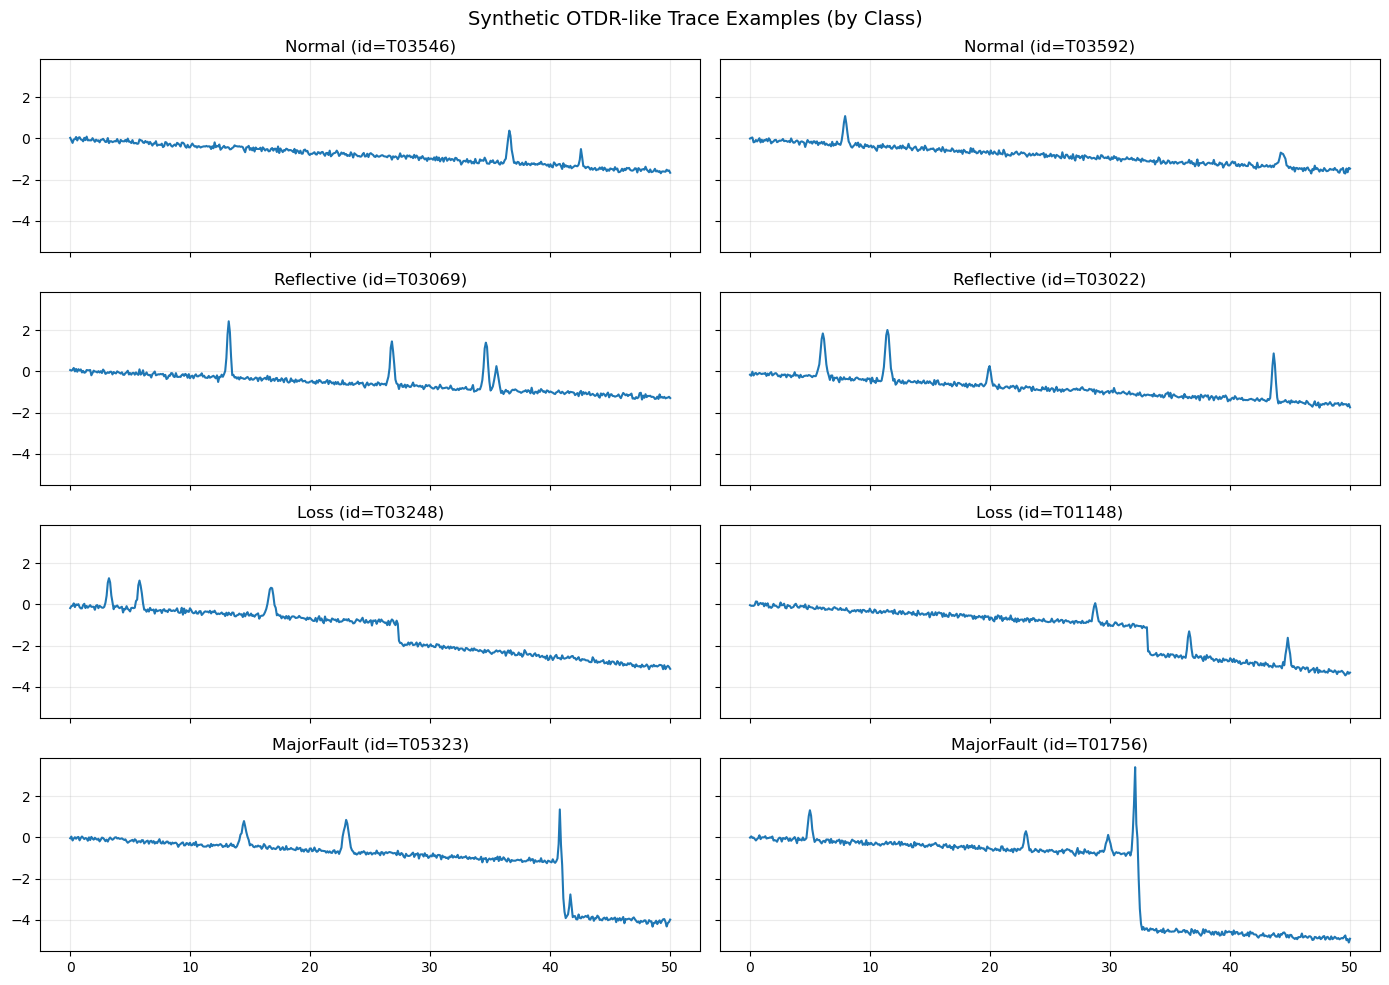

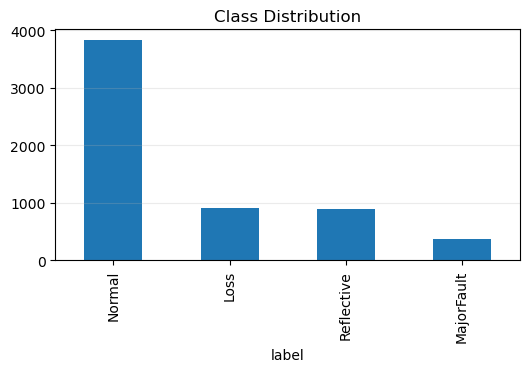

In [4]:
label_names = {0: "Normal", 1: "Reflective", 2: "Loss", 3: "MajorFault"}

def plot_examples(meta, traces, d, n_each=2):
    fig, axes = plt.subplots(4, n_each, figsize=(14, 10), sharex=True, sharey=True)
    for cls in [0,1,2,3]:
        idxs = meta.index[meta['label'] == cls].to_list()
        pick = np.random.choice(idxs, size=n_each, replace=False)
        for j, idx in enumerate(pick):
            ax = axes[cls, j]
            ax.plot(d, traces[idx], lw=1.5)
            ax.set_title(f"{label_names[cls]} (id={meta.loc[idx,'trace_id']})")
            ax.grid(True, alpha=0.25)
    fig.suptitle("Synthetic OTDR-like Trace Examples (by Class)", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_examples(meta_df, trace_mat, d_axis, n_each=2)

plt.figure(figsize=(6,3))
meta_df['label'].map(label_names).value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.grid(axis='y', alpha=0.25)
plt.show()

## 2) Feature engineering (≥10 features)

We compute interpretable OTDR-inspired features to support classic ML model families.


In [5]:
def _linear_slope(x, y):
    # Simple least squares slope
    x = np.asarray(x)
    y = np.asarray(y)
    x0 = x - x.mean()
    denom = (x0**2).sum() + 1e-12
    return (x0 * (y - y.mean())).sum() / denom

def _count_peaks(y, thresh):
    # naive local maxima count
    y = np.asarray(y)
    peaks = (y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]) & (y[1:-1] > thresh)
    return int(peaks.sum())

def _max_peak(y):
    return float(np.max(y))

def _distance_to_max_peak(d, y):
    i = int(np.argmax(y))
    return float(d[i])

def _peak_sharpness(y):
    # curvature proxy around max peak
    i = int(np.argmax(y))
    i0 = max(1, i-2)
    i1 = min(len(y)-2, i+2)
    seg = y[i0:i1+1]
    if len(seg) < 3:
        return 0.0
    # second difference magnitude
    dd = np.diff(seg, n=2)
    return float(np.max(np.abs(dd)))

def _largest_step_loss(y):
    # max negative jump between adjacent points (rough)
    dy = np.diff(y)
    return float(np.max(-dy))  # large positive means big drop

def _cumulative_step_loss(y, step_thresh=0.12):
    dy = np.diff(y)
    drops = -dy
    return float(drops[drops > step_thresh].sum())

def _end_drop_indicator(y, frac=0.1, drop_thresh=1.0):
    n = len(y)
    k = int(n*frac)
    head = y[:k].mean()
    tail = y[-k:].mean()
    return int((head - tail) > drop_thresh)

def _post_event_energy(y):
    # mean after max peak
    i = int(np.argmax(y))
    return float(np.mean(y[i:]))

def extract_features(meta, traces, d):
    feats = []
    for i in range(traces.shape[0]):
        y = traces[i]
        global_slope = _linear_slope(d, y)

        # segmented slopes
        n = len(y)
        a = n//3
        b = 2*n//3
        slope_early = _linear_slope(d[:a], y[:a])
        slope_late = _linear_slope(d[b:], y[b:])
        slope_diff = slope_late - slope_early

        mu = float(np.mean(y))
        sigma = float(np.std(y))

        # peak features
        thresh = mu + 2.5*sigma
        peak_count = _count_peaks(y, thresh=thresh)
        max_peak = _max_peak(y)
        peak_loc_km = _distance_to_max_peak(d, y)
        sharpness = _peak_sharpness(y)

        # step-loss / termination features
        largest_step = _largest_step_loss(y)
        cum_step = _cumulative_step_loss(y)
        end_drop = _end_drop_indicator(y)
        post_energy = _post_event_energy(y)

        feats.append({
            "global_slope": global_slope,
            "slope_early": slope_early,
            "slope_late": slope_late,
            "slope_diff": slope_diff,
            "mean_amp": mu,
            "std_amp": sigma,
            "peak_count": peak_count,
            "max_peak": max_peak,
            "peak_sharpness": sharpness,
            "peak_loc_km": peak_loc_km,
            "largest_step_loss": largest_step,
            "cumulative_step_loss": cum_step,
            "end_drop": end_drop,
            "post_event_mean": post_energy,
        })

    feat_df = pd.DataFrame(feats)
    full = pd.concat([meta.reset_index(drop=True), feat_df], axis=1)
    return full

full_df = extract_features(meta_df, trace_mat, d_axis)
full_df.head()

,trace_id,wavelength,pulse_width_ns,range_km,device_id,label,global_slope,slope_early,slope_late,slope_diff,mean_amp,std_amp,peak_count,max_peak,peak_sharpness,peak_loc_km,largest_step_loss,cumulative_step_loss,end_drop,post_event_mean
0,T00000,1550,30,50,OTDR_C,0,-0.029920,-0.030478,-0.029196,0.001282,-0.669623,0.444631,0,0.217030,0.380616,0.587084,0.399647,11.204668,1,-0.678789
1,T00001,1550,100,50,OTDR_C,3,-0.104413,-0.031306,-0.029433,0.001873,-1.727170,1.704605,1,3.564300,3.593016,30.332681,2.164003,17.751337,1,-3.721208
2,T00002,1550,100,50,OTDR_A,1,-0.030181,-0.024461,-0.030142,-0.005681,-0.707717,0.509884,4,1.494143,1.221238,18.003914,1.107626,18.456539,1,-0.972640
3,T00003,1550,10,50,OTDR_B,0,-0.028735,-0.020986,-0.033380,-0.012394,-0.678006,0.433532,1,0.747203,0.292988,11.350294,0.478173,12.802497,1,-0.834039
4,T00004,1550,10,50,OTDR_A,1,-0.030231,-0.027628,-0.033234,-0.005607,-0.622533,0.490786,2,2.036254,0.762772,8.317025,0.845747,15.284408,1,-0.743712


## 3) Train/test split

In [6]:
target = "label"
drop_cols = ["trace_id", target]

X = full_df.drop(columns=drop_cols)
y = full_df[target]

cat_cols = ["device_id"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train class distribution:\n", y_train.map(label_names).value_counts(normalize=True))

Train size: (4800, 18) Test size: (1200, 18)
Train class distribution:
 label
Normal        0.637083
Loss          0.152917
Reflective    0.149375
MajorFault    0.060625
Name: proportion, dtype: float64


## 4) Model family A: Logistic Regression (interpretable baseline)

In [7]:
from sklearn.preprocessing import StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

logreg = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED
)

clf_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", logreg)
])

clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)
macro_f1_lr = f1_score(y_test, pred_lr, average="macro")
print("LogReg macro-F1:", round(macro_f1_lr, 4))
print(classification_report(y_test, pred_lr, target_names=[label_names[i] for i in [0,1,2,3]]))

LogReg macro-F1: 0.9758
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       764
  Reflective       0.89      0.96      0.92       179
        Loss       1.00      1.00      1.00       184
  MajorFault       1.00      1.00      1.00        73

    accuracy                           0.98      1200
   macro avg       0.97      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



## 5) Model family B: Random Forest (nonlinear classical ML)

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1
)

clf_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", rf)
])

clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)
macro_f1_rf = f1_score(y_test, pred_rf, average="macro")
print("RF macro-F1:", round(macro_f1_rf, 4))
print(classification_report(y_test, pred_rf, target_names=[label_names[i] for i in [0,1,2,3]]))

RF macro-F1: 0.981
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       764
  Reflective       0.94      0.93      0.94       179
        Loss       1.00      1.00      1.00       184
  MajorFault       1.00      1.00      1.00        73

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



## 6) Confusion matrices + quick error view

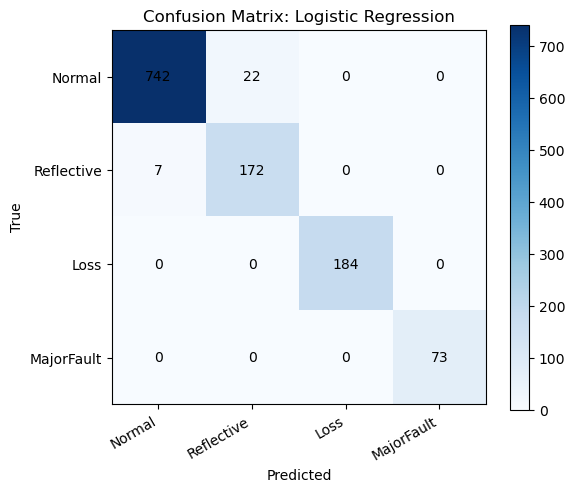

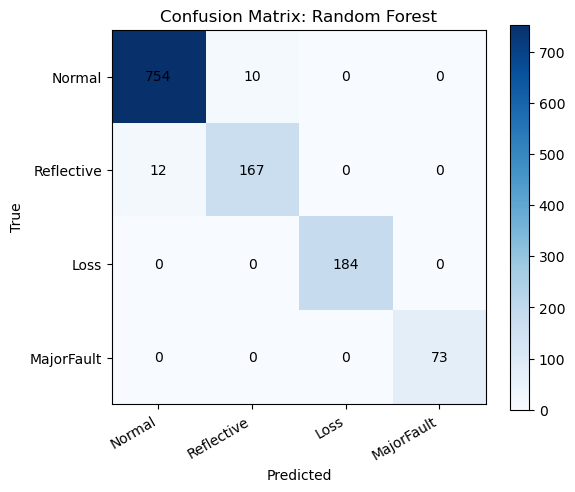

In [9]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def plot_cm_matplotlib(y_true, y_pred, title):
    labels = [0,1,2,3]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels([label_names[i] for i in labels], rotation=30, ha="right")
    ax.set_yticklabels([label_names[i] for i in labels])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_cm_matplotlib(y_test, pred_lr, "Confusion Matrix: Logistic Regression")
plot_cm_matplotlib(y_test, pred_rf, "Confusion Matrix: Random Forest")

## 7) Save artifacts (models + metrics)

We save trained pipelines and a metrics summary for reproducibility and reporting.

In [10]:
import joblib

joblib.dump(clf_lr, os.path.join(OUT_DIR, "model_logreg.joblib"))
joblib.dump(clf_rf, os.path.join(OUT_DIR, "model_rf.joblib"))

metrics = {
    "macro_f1_logreg": float(macro_f1_lr),
    "macro_f1_rf": float(macro_f1_rf),
    "n_records": int(len(full_df)),
    "n_features_engineered": int(len([c for c in full_df.columns if c not in ["trace_id","label","device_id","wavelength","pulse_width_ns","range_km"]])),
    "feature_columns": list(X.columns),
    "label_names": label_names
}

with open(os.path.join(OUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", os.listdir(OUT_DIR))
metrics

Saved: ['metrics.json', 'model_logreg.joblib', 'model_rf.joblib']


{'macro_f1_logreg': 0.9757711983187708,
 'macro_f1_rf': 0.9809557905559227,
 'n_records': 6000,
 'n_features_engineered': 14,
 'feature_columns': ['wavelength',
  'pulse_width_ns',
  'range_km',
  'device_id',
  'global_slope',
  'slope_early',
  'slope_late',
  'slope_diff',
  'mean_amp',
  'std_amp',
  'peak_count',
  'max_peak',
  'peak_sharpness',
  'peak_loc_km',
  'largest_step_loss',
  'cumulative_step_loss',
  'end_drop',
  'post_event_mean'],
 'label_names': {0: 'Normal', 1: 'Reflective', 2: 'Loss', 3: 'MajorFault'}}

## 8) (Optional) Feature importance for Random Forest

This supports explainability and Responsible AI documentation.

In [11]:
# Extract feature names after preprocessing
ohe = clf_rf.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = cat_feature_names + num_cols

importances = clf_rf.named_steps["model"].feature_importances_
imp = pd.DataFrame({"feature": all_feature_names, "importance": importances}).sort_values("importance", ascending=False)
imp.head(15)

,feature,importance
11,std_amp,0.150772
16,largest_step_loss,0.131132
19,post_event_mean,0.116518
17,cumulative_step_loss,0.103438
6,global_slope,0.099623
10,mean_amp,0.093287
14,peak_sharpness,0.081184
13,max_peak,0.078637
12,peak_count,0.051827
8,slope_late,0.036712


In [12]:
import json

with open("artifacts/metrics.json", "r") as f:
    metrics = json.load(f)

print("Macro-F1 (LogReg):", metrics["macro_f1_logreg"])
print("Macro-F1 (RandomForest):", metrics["macro_f1_rf"])

Macro-F1 (LogReg): 0.9757711983187708
Macro-F1 (RandomForest): 0.9809557905559227
